# Identificación de municipios vecinos

Este notebook identifica los municipios **colindantes** del municipio de interés: aquellos cuyo límite territorial comparte frontera con el municipio seleccionado.

**Fuente:** Marco Geoestadístico Nacional (MGN) del INEGI.

**Flujo de trabajo:**
1. Ejecuta las celdas hasta la sección 3 (carga de datos).
2. Selecciona estado y municipio en los menús desplegables.
3. Ejecuta las celdas restantes.

In [21]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import contextily as ctx
import ipywidgets as widgets
from IPython.display import display, clear_output
from pathlib import Path

## 1. Configuración

In [22]:
# Ruta al shapefile de municipios del MGN
RUTA_MGN = Path("C:/SCINCE 2020/00_NAL/cartografia/municipal.shp")

# Carpeta donde se guardan los resultados
RUTA_SALIDA = Path("../datos/vecinos")

## 2. Carga del Marco Geoestadístico Nacional

In [23]:
assert RUTA_MGN.exists(), (
    f"No se encontró el shapefile en {RUTA_MGN}. "
    "Revisa la ruta en la celda de configuración."
)

municipios = gpd.read_file(RUTA_MGN)

# Extraer CVE_ENT y CVE_MUN desde CVEGEO (ej. "14039" → "14", "039")
municipios["CVE_ENT"] = municipios["CVEGEO"].astype(str).str.zfill(5).str[:2]
municipios["CVE_MUN"] = municipios["CVEGEO"].astype(str).str.zfill(5).str[2:]

print(f"Total de municipios cargados: {len(municipios)}")
print(f"CRS: {municipios.crs}")
municipios[["CVEGEO", "CVE_ENT", "CVE_MUN", "NOM_ENT", "NOMGEO"]].head(3)

Total de municipios cargados: 2469
CRS: EPSG:6372


,CVEGEO,CVE_ENT,CVE_MUN,NOM_ENT,NOMGEO
0,01001,01,001,Aguascalientes,Aguascalientes
1,01002,01,002,Aguascalientes,Asientos
2,01003,01,003,Aguascalientes,Calvillo


## 3. Selección interactiva del municipio de interés

Elige primero el **estado** y luego el **municipio**. Después ejecuta las celdas siguientes.

In [24]:
estados = sorted(municipios["NOM_ENT"].dropna().unique().tolist())

w_estado = widgets.Dropdown(
    options=estados,
    description="Estado:",
    layout=widgets.Layout(width="420px"),
    style={"description_width": "80px"},
)

w_municipio = widgets.Dropdown(
    options=[],
    description="Municipio:",
    layout=widgets.Layout(width="420px"),
    style={"description_width": "80px"},
)

out_info = widgets.Output()

def actualizar_municipios(change):
    muns = sorted(
        municipios.loc[municipios["NOM_ENT"] == change["new"], "NOMGEO"]
        .dropna().unique().tolist()
    )
    w_municipio.options = muns
    w_municipio.value = muns[0] if muns else None

def mostrar_info(change):
    with out_info:
        clear_output()
        if w_municipio.value:
            fila = municipios[
                (municipios["NOM_ENT"] == w_estado.value) &
                (municipios["NOMGEO"]  == w_municipio.value)
            ].iloc[0]
            print(f"✔  {fila['NOMGEO']}, {fila['NOM_ENT']}  "
                  f"(CVEGEO: {fila['CVEGEO']})")

w_estado.observe(actualizar_municipios, names="value")
w_municipio.observe(mostrar_info, names="value")

actualizar_municipios({"new": estados[0]})

display(widgets.VBox([
    widgets.Label("Selecciona el municipio de interés:"),
    w_estado,
    w_municipio,
    out_info,
]))

## 4. Confirmar selección

> Ejecuta esta celda **después** de haber seleccionado el municipio en los dropdowns.

In [25]:
mascara = (
    (municipios["NOM_ENT"] == w_estado.value) &
    (municipios["NOMGEO"]  == w_municipio.value)
)

assert mascara.sum() == 1, (
    f"Se encontraron {mascara.sum()} registros para "
    f"'{w_municipio.value}, {w_estado.value}'. "
    "El shapefile puede tener duplicados."
)

mun_interes = municipios[mascara].iloc[0]
idx_interes  = municipios.index[mascara][0]
geom_interes = municipios.at[idx_interes, "geometry"]

print(f"Municipio de interés : {mun_interes['NOMGEO']}, {mun_interes['NOM_ENT']}")
print(f"CVEGEO               : {mun_interes['CVEGEO']}")

Municipio de interés : Benito Juárez, Ciudad de México
CVEGEO               : 09014


## 5. Municipios colindantes

Un municipio es **colindante** si su l�mite territorial comparte frontera con el municipio de inter�s.

Los datos del MGN suelen tener micro-gaps o micro-solapamientos de pocos metros entre pol�gonos adyacentes,
producto de la digitalizaci�n. Para compensarlo se aplica un **buffer de tolerancia** al pol�gono de inter�s
antes de buscar intersecciones � cualquier municipio cuya geometr�a entre en contacto con esa zona expandida
es considerado colindante.

In [26]:
# Tolerancia en metros para compensar gaps de digitalizaci�n del MGN
TOLERANCIA_M = 50

geom_buffer = geom_interes.buffer(TOLERANCIA_M)

colindantes_mask = (
    municipios.geometry.intersects(geom_buffer)
) & (municipios.index != idx_interes)

vecinos = municipios[colindantes_mask].copy()

print(f"Municipios colindantes: {len(vecinos)}")
vecinos[["CVE_ENT", "CVE_MUN", "NOM_ENT", "NOMGEO"]].reset_index(drop=True)

Municipios colindantes: 6


,CVE_ENT,CVE_MUN,NOM_ENT,NOMGEO
0,09,003,Ciudad de México,Coyoacán
1,09,006,Ciudad de México,Iztacalco
2,09,007,Ciudad de México,Iztapalapa
3,09,010,Ciudad de México,Álvaro Obregón
4,09,015,Ciudad de México,Cuauhtémoc
5,09,016,Ciudad de México,Miguel Hidalgo


## 6. Visualización

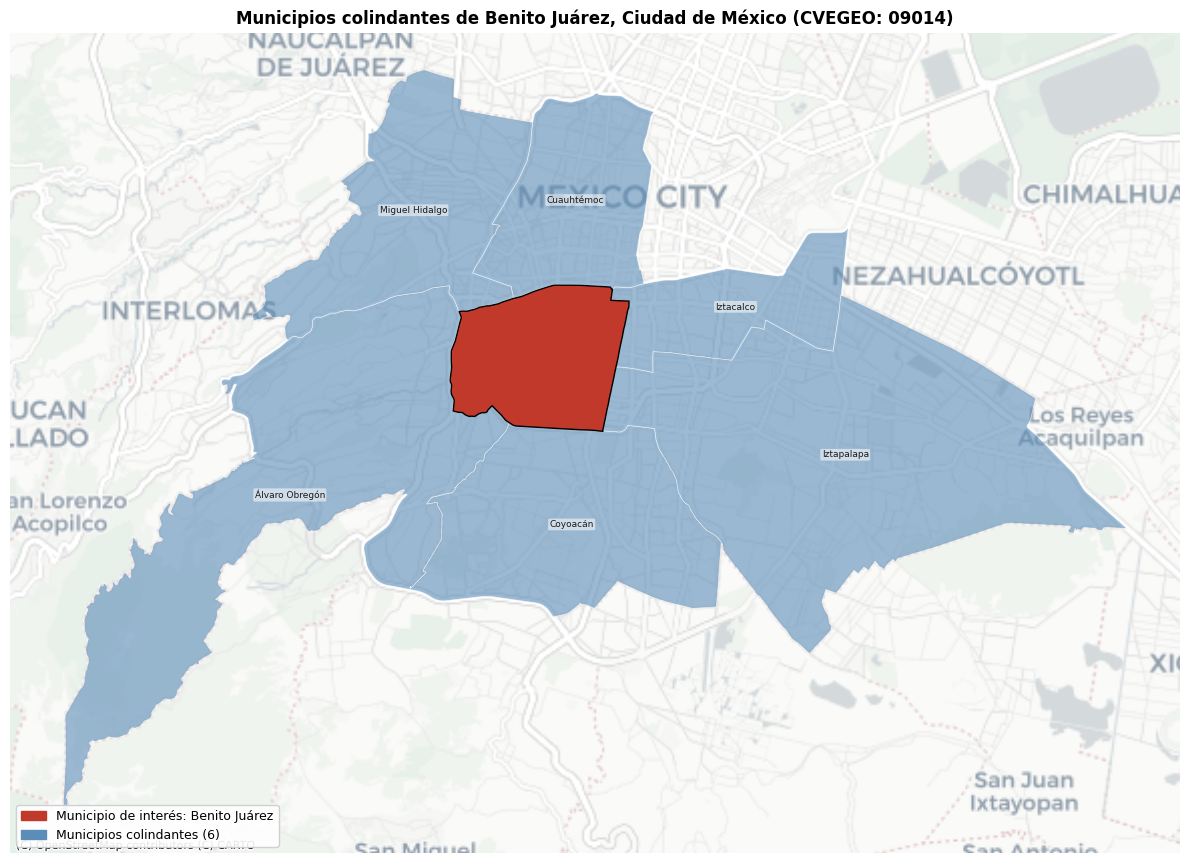

Mapa guardado.


In [27]:
CRS_VIZ = "EPSG:3857"  # Web Mercator para contextily

mun_interes_plot = municipios.loc[[idx_interes]].to_crs(CRS_VIZ)
vecinos_plot     = vecinos.to_crs(CRS_VIZ)

fig, ax = plt.subplots(figsize=(12, 10))

vecinos_plot.plot(
    ax=ax, color="#5b8db8", alpha=0.6, edgecolor="white", linewidth=0.5
)
mun_interes_plot.plot(
    ax=ax, color="#c0392b", edgecolor="black", linewidth=1.0, zorder=5
)

# Etiquetas
for _, row in vecinos_plot.iterrows():
    cx, cy = row.geometry.centroid.x, row.geometry.centroid.y
    ax.annotate(
        row["NOMGEO"], xy=(cx, cy),
        fontsize=6.5, ha="center", va="center", color="#1a1a1a",
        bbox=dict(boxstyle="round,pad=0.15", fc="white", alpha=0.55, ec="none")
    )

try:
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom="auto")
except Exception:
    pass

leyenda = [
    mpatches.Patch(color="#c0392b",
                   label=f"Municipio de interés: {mun_interes['NOMGEO']}"),
    mpatches.Patch(color="#5b8db8",
                   label=f"Municipios colindantes ({len(vecinos)})"),
]
ax.legend(handles=leyenda, loc="lower left", fontsize=9, framealpha=0.9)
ax.set_title(
    f"Municipios colindantes de {mun_interes['NOMGEO']}, "
    f"{mun_interes['NOM_ENT']} (CVEGEO: {mun_interes['CVEGEO']})",
    fontsize=12, fontweight="bold"
)
ax.axis("off")
plt.tight_layout()

RUTA_SALIDA.mkdir(parents=True, exist_ok=True)
fig.savefig(
    RUTA_SALIDA / f"mapa_vecinos_{mun_interes['CVEGEO']}.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Mapa guardado.")

## 7. Exportación de resultados

In [ ]:
import pandas as pd

prefijo   = mun_interes["CVEGEO"]

mun_export = municipios[mascara].copy()
mun_export["rol"] = "municipio_interes"

vec_export = vecinos.copy()
vec_export["rol"] = "colindante"

combinado = gpd.GeoDataFrame(
    pd.concat([mun_export, vec_export], ignore_index=True),
    geometry="geometry", crs=municipios.crs,
)

gpkg_path = RUTA_SALIDA / f"vecinos_{prefijo}.gpkg"
combinado.to_file(gpkg_path, layer="municipios", driver="GPKG")

csv_path = RUTA_SALIDA / f"vecinos_{prefijo}.csv"
(
    combinado[["CVEGEO", "CVE_ENT", "CVE_MUN", "NOM_ENT", "NOMGEO", "rol"]]
    .reset_index(drop=True)
    .to_csv(csv_path, index=False, encoding="utf-8-sig")
)

print(f"GeoPackage: {gpkg_path}")
print(f"CSV       : {csv_path}")
combinado[["CVEGEO", "CVE_ENT", "CVE_MUN", "NOM_ENT", "NOMGEO", "rol"]].reset_index(drop=True)